# CT phantom preprocessing pipeline appling paper methods
**Pipeline:** HU conversion → Fat-based normalization → Windowing → Median filter → Threshold segmentation  
**Dataset:** FANTOCCIO — series S2010 and S3010 (571/577 slices, 512×512)

---
### Paper references

| ID | Authors | Year | Journal | Relevance |
|---|---|---|---|---|
| **Nelson** | Nelson et al. | 2008 | Medical Physics | HU reference values for breast tissues; 5-point median filter; Gaussian histogram fitting |
| **Chen** | Chen Z. | 2008 | Computerized Medical Imaging and Graphics | Valley-seeking and five-subinterval threshold segmentation algorithms |
| **Caballo** | Caballo et al. | 2018 | Medical Physics | Unsupervised segmentation; bimodal histogram; DSC benchmark |
| **Prionas** | Prionas et al. | 2010 | Radiology | Fat-based intensity normalization; windowing WW=350 WL=25; lesion HU values |

---
### Folder structure
```
output/
   ├── preprocessing_data/paper_based/
   │   ├── S2010/  (hu_volume.npy, normalized_volume.npy, windowed_volume.npy, filtered_volume.npy, spacing.npy)
   │   └── S3010/  (hu_volume.npy, normalized_volume.npy, windowed_volume.npy, filtered_volume.npy, spacing.npy)
   └── figures/paper_based/
       └── pipeline_S2010.png, segmentation_S2010.png, segA..D_*.png, comparison_*.png
```


In [1]:
# ============================================================
# CELL 1 - Import libraries and create output folder structure
# ============================================================

import os
import numpy as np
import pydicom
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter
from scipy.signal import find_peaks

OUTPUT_DIRS = [
    "./output/preprocessing_data/paper_based/S2010",
    "./output/preprocessing_data/paper_based/S3010",
    "./output/figures/paper_based",
]
for d in OUTPUT_DIRS:
    os.makedirs(d, exist_ok=True)

SERIES = {
    "S2010": "./dataset/FANTOCCIO/S72990/S2010",
    "S3010": "./dataset/FANTOCCIO/S72990/S3010",
}

print("Libraries imported and output structure ready.")


Libraries imported and output structure ready.


---
## Step 1 - Hounsfield Unit (HU) Conversion

**Formula:** `HU = pixel_value x RescaleSlope + RescaleIntercept`

Raw DICOM pixel values are scanner-dependent. The HU scale is the only standardised unit
comparable across scanners. Without this conversion no threshold has clinical meaning.

**Reference HU values [Nelson2008, Prionas2010]:**

| Tissue | HU |
|---|---|
| Air | -1000 |
| Adipose | -100 / -50 |
| Fat (dedicated breast CT) | ~126 HU [Nelson2008] |
| Glandular / skin | ~152 HU [Nelson2008] |
| Malignant lesion (post-contrast) | +55.9 HU above baseline [Prionas2010] |
| Benign lesion (post-contrast) | +17.6 HU above baseline [Prionas2010] |
| Bone | 200-400 |
| Metal (phantom seed) | >1000 |


> **Note [Nelson]:** Fat (~126 HU) vs glandular (~152 HU) differ by only ~26 HU, that why simple global thresholding alone is insufficient.


In [2]:
# ============================================================
# CELL 2 - STEP 1: Load DICOM volume and convert to HU
# Ref: Nelson, Prionas
# ============================================================

def load_dicom_volume_hu(folder_path, series_name):
    """
    Load all DICOM slices, sort by SliceLocation, convert to HU.
    HU = pixel_value x RescaleSlope + RescaleIntercept  [Nelson]
    """
    valid_paths = []
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            ds = pydicom.dcmread(fpath, stop_before_pixels=True)
            if hasattr(ds, 'Rows') and hasattr(ds, 'Columns'):
                valid_paths.append(fpath)
        except Exception:
            pass
    if not valid_paths:
        raise FileNotFoundError(f"No valid DICOM files in {folder_path}")

    def get_z(fpath):
        ds = pydicom.dcmread(fpath, stop_before_pixels=True)
        if hasattr(ds, 'SliceLocation'):  return float(ds.SliceLocation)
        if hasattr(ds, 'InstanceNumber'): return float(ds.InstanceNumber)
        return 0.0

    valid_paths.sort(key=get_z)
    print(f"[{series_name}] Slices found and sorted: {len(valid_paths)}")

    slices_hu, first_ds = [], None
    for fpath in valid_paths:
        ds        = pydicom.dcmread(fpath)
        slope     = float(ds.RescaleSlope)     if hasattr(ds,'RescaleSlope')     else 1.0
        intercept = float(ds.RescaleIntercept) if hasattr(ds,'RescaleIntercept') else 0.0
        slices_hu.append(ds.pixel_array.astype(np.float32) * slope + intercept)
        if first_ds is None: first_ds = ds

    hu_volume = np.stack(slices_hu, axis=0)
    z_mm   = float(first_ds.SliceThickness) if hasattr(first_ds,'SliceThickness') else 0.0
    px     = first_ds.PixelSpacing if hasattr(first_ds,'PixelSpacing') else [1.0,1.0]
    spacing = (z_mm, float(px[0]), float(px[1]))

    out_dir = f"./output/preprocessing_data/paper_based/{series_name}"
    np.save(f"{out_dir}/hu_volume.npy", hu_volume)
    np.save(f"{out_dir}/spacing.npy",   np.array(spacing))

    print(f"[{series_name}] Shape:  {hu_volume.shape}")
    print(f"[{series_name}] HU:     min={hu_volume.min():.0f}  max={hu_volume.max():.0f}")
    print(f"[{series_name}] Voxel:  Z={spacing[0]:.3f} Y={spacing[1]:.4f} X={spacing[2]:.4f} mm")
    print(f"[{series_name}] Ref [Nelson]: fat ~126 HU | glandular ~152 HU")
    print("-" * 60)
    return hu_volume, spacing


print("=== STEP 1: HU Conversion ===")
hu_S2010, spacing_S2010 = load_dicom_volume_hu(SERIES["S2010"], "S2010")
hu_S3010, spacing_S3010 = load_dicom_volume_hu(SERIES["S3010"], "S3010")


=== STEP 1: HU Conversion ===
[S2010] Slices found and sorted: 571
[S2010] Shape:  (571, 512, 512)
[S2010] HU:     min=-1024  max=3071
[S2010] Voxel:  Z=0.670 Y=0.3789 X=0.3789 mm
[S2010] Ref [Nelson]: fat ~126 HU | glandular ~152 HU
------------------------------------------------------------
[S3010] Slices found and sorted: 577
[S3010] Shape:  (577, 512, 512)
[S3010] HU:     min=-1024  max=3071
[S3010] Voxel:  Z=0.670 Y=0.3340 X=0.3340 mm
[S3010] Ref [Nelson]: fat ~126 HU | glandular ~152 HU
------------------------------------------------------------


---
## Step 2 - Fat-based Intensity Normalization

**Method [Prionas]:** `HU_norm = HU_voxel - HU_mean_fat`

Adipose tissue is the most stable internal reference: constant HU across scanners,
unaffected by contrast agent, always present in breast CT.

> **[Prionas]:** Enhancement = `(HU_lesion_post - HU_fat_post) - (HU_lesion_pre - HU_fat_pre)`
> Fat subtracted as internal reference to remove inter-session fluctuations.


In [3]:
# ============================================================
# CELL 3 - STEP 2: Fat-based intensity normalization
# Ref: Prionas
# ============================================================

def normalize_by_fat(hu_volume, series_name, fat_hu_min=-200, fat_hu_max=-50):
    """
    Subtract mean HU of fat voxels as internal baseline [Prionas].
    After: fat ~0 HU | glandular ~26 HU (152-126, [Nelson])
    """
    fat_mask   = (hu_volume >= fat_hu_min) & (hu_volume <= fat_hu_max)
    fat_voxels = hu_volume[fat_mask]
    if fat_voxels.size == 0:
        print(f"[{series_name}] WARNING: No fat voxels found. Skipping."); return hu_volume, 0.0
    hu_mean_fat = float(np.mean(fat_voxels))
    normalized  = hu_volume - hu_mean_fat
    out_path = f"./output/preprocessing_data/paper_based/{series_name}/normalized_volume.npy"
    np.save(out_path, normalized)
    print(f"[{series_name}] Fat voxels: {fat_voxels.size:,} | mean HU fat: {hu_mean_fat:.2f} HU (lit ~126 [Nelson])")
    print(f"[{series_name}] Saved to: {out_path}")
    print("-" * 60)
    return normalized, hu_mean_fat


print("=== STEP 2: Fat-based Normalization [Prionas] ===")
norm_S2010, fat_hu_S2010 = normalize_by_fat(hu_S2010, "S2010")
norm_S3010, fat_hu_S3010 = normalize_by_fat(hu_S3010, "S3010")


=== STEP 2: Fat-based Normalization [Prionas] ===
[S2010] Fat voxels: 6,882,905 | mean HU fat: -157.81 HU (lit ~126 [Nelson])
[S2010] Saved to: ./output/preprocessing_data/paper_based/S2010/normalized_volume.npy
------------------------------------------------------------
[S3010] Fat voxels: 11,321,434 | mean HU fat: -152.19 HU (lit ~126 [Nelson])
[S3010] Saved to: ./output/preprocessing_data/paper_based/S3010/normalized_volume.npy
------------------------------------------------------------


---
## Step 3 - Windowing

**Parameters [Prionas]:** WW=350 HU | WL=25 HU → range [-150, +200] HU

Clinically validated for breast CT. Keeps adipose (-100 HU), glandular (+152 HU), lesions.
Clips bone and metal (>200 HU) to remove beam-hardening artefacts.

> Applied on the **original HU volume** (not normalized) to preserve the absolute clinical meaning.


In [4]:
# ============================================================
# CELL 4 - STEP 3: Windowing
# Ref: Prionas (WW=350, WL=25)
# Applied on the ORIGINAL HU volume
# ============================================================

def apply_windowing(hu_volume, series_name, window_width=350, window_level=25):
    """CT windowing for breast CT [Prionas]: WW=350, WL=25 -> [-150, +200] HU."""
    lower = window_level - window_width / 2
    upper = window_level + window_width / 2
    windowed = np.clip(hu_volume, lower, upper)
    windowed = (windowed - lower) / (upper - lower)
    out_path = f"./output/preprocessing_data/paper_based/{series_name}/windowed_volume.npy"
    np.save(out_path, windowed)
    print(f"[{series_name}] WW={window_width} WL={window_level} -> [{lower:.0f}, {upper:.0f}] HU  [Prionas]")
    print(f"[{series_name}] Saved to: {out_path}")
    print("-" * 60)
    return windowed


print("=== STEP 3: Windowing [Prionas] ===")
windowed_S2010 = apply_windowing(hu_S2010, "S2010")
windowed_S3010 = apply_windowing(hu_S3010, "S3010")


=== STEP 3: Windowing [Prionas] ===
[S2010] WW=350 WL=25 -> [-150, 200] HU  [Prionas]
[S2010] Saved to: ./output/preprocessing_data/paper_based/S2010/windowed_volume.npy
------------------------------------------------------------
[S3010] WW=350 WL=25 -> [-150, 200] HU  [Prionas]
[S3010] Saved to: ./output/preprocessing_data/paper_based/S3010/windowed_volume.npy
------------------------------------------------------------


---
## Step 4 - Noise Reduction: 5-point Median Filter

**Method [Nelson]:** 5-point median filter slice by slice before histogram analysis.

Edge-preserving: reduces Poisson noise without blurring tissue boundaries.
Critical given the narrow ~26 HU gap between fat and glandular tissue.


In [5]:
# ============================================================
# CELL 5 - STEP 4: 5-point median filter
# Ref: Nelson
# ============================================================

def apply_median_filter(windowed_volume, series_name, kernel_size=5):
    """5-point median filter slice by slice [Nelson]."""
    filtered_volume = np.zeros_like(windowed_volume)
    n = windowed_volume.shape[0]
    for i in range(n):
        filtered_volume[i] = median_filter(windowed_volume[i], size=kernel_size)
        if (i + 1) % 100 == 0: print(f"  [{series_name}] {i+1}/{n} filtered...")
    out_path = f"./output/preprocessing_data/paper_based/{series_name}/filtered_volume.npy"
    np.save(out_path, filtered_volume)
    print(f"[{series_name}] Median filter {kernel_size}x{kernel_size} complete [Nelson]")
    print(f"[{series_name}] Saved to: {out_path}")
    print("-" * 60)
    return filtered_volume


print("=== STEP 4: 5-point Median Filter [Nelson] ===")
filtered_S2010 = apply_median_filter(windowed_S2010, "S2010")
filtered_S3010 = apply_median_filter(windowed_S3010, "S3010")


=== STEP 4: 5-point Median Filter [Nelson] ===
  [S2010] 100/571 filtered...
  [S2010] 200/571 filtered...
  [S2010] 300/571 filtered...
  [S2010] 400/571 filtered...
  [S2010] 500/571 filtered...
[S2010] Median filter 5x5 complete [Nelson]
[S2010] Saved to: ./output/preprocessing_data/paper_based/S2010/filtered_volume.npy
------------------------------------------------------------
  [S3010] 100/577 filtered...
  [S3010] 200/577 filtered...
  [S3010] 300/577 filtered...
  [S3010] 400/577 filtered...
  [S3010] 500/577 filtered...
[S3010] Median filter 5x5 complete [Nelson]
[S3010] Saved to: ./output/preprocessing_data/paper_based/S3010/filtered_volume.npy
------------------------------------------------------------


---
## Visualization - Full pipeline comparison

4 rows × 3 slices (25% / 50% / 75% of volume depth).


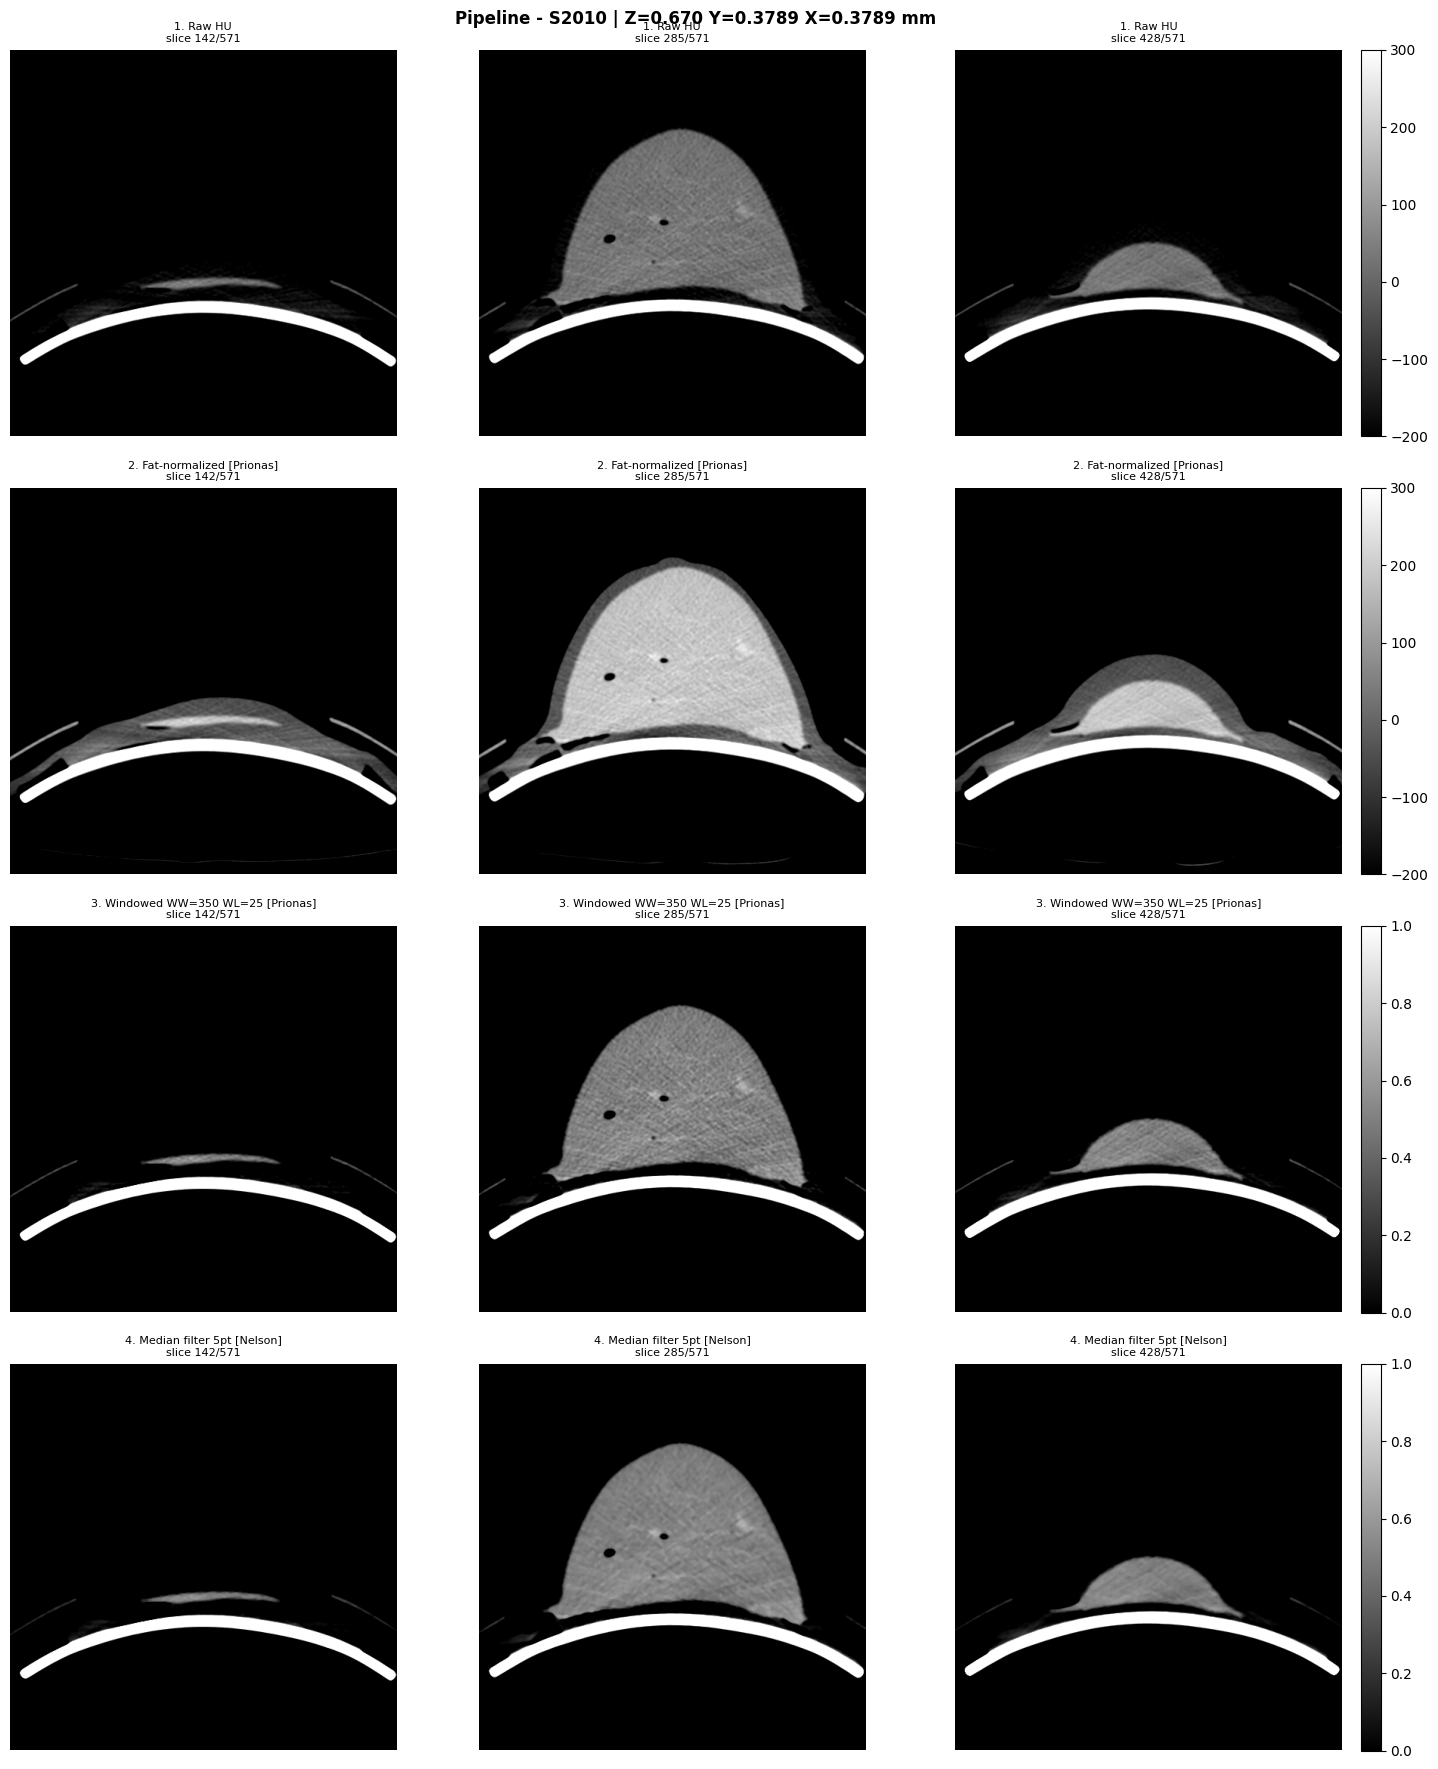

Saved: ./output/figures/paper_based/pipeline_S2010.png


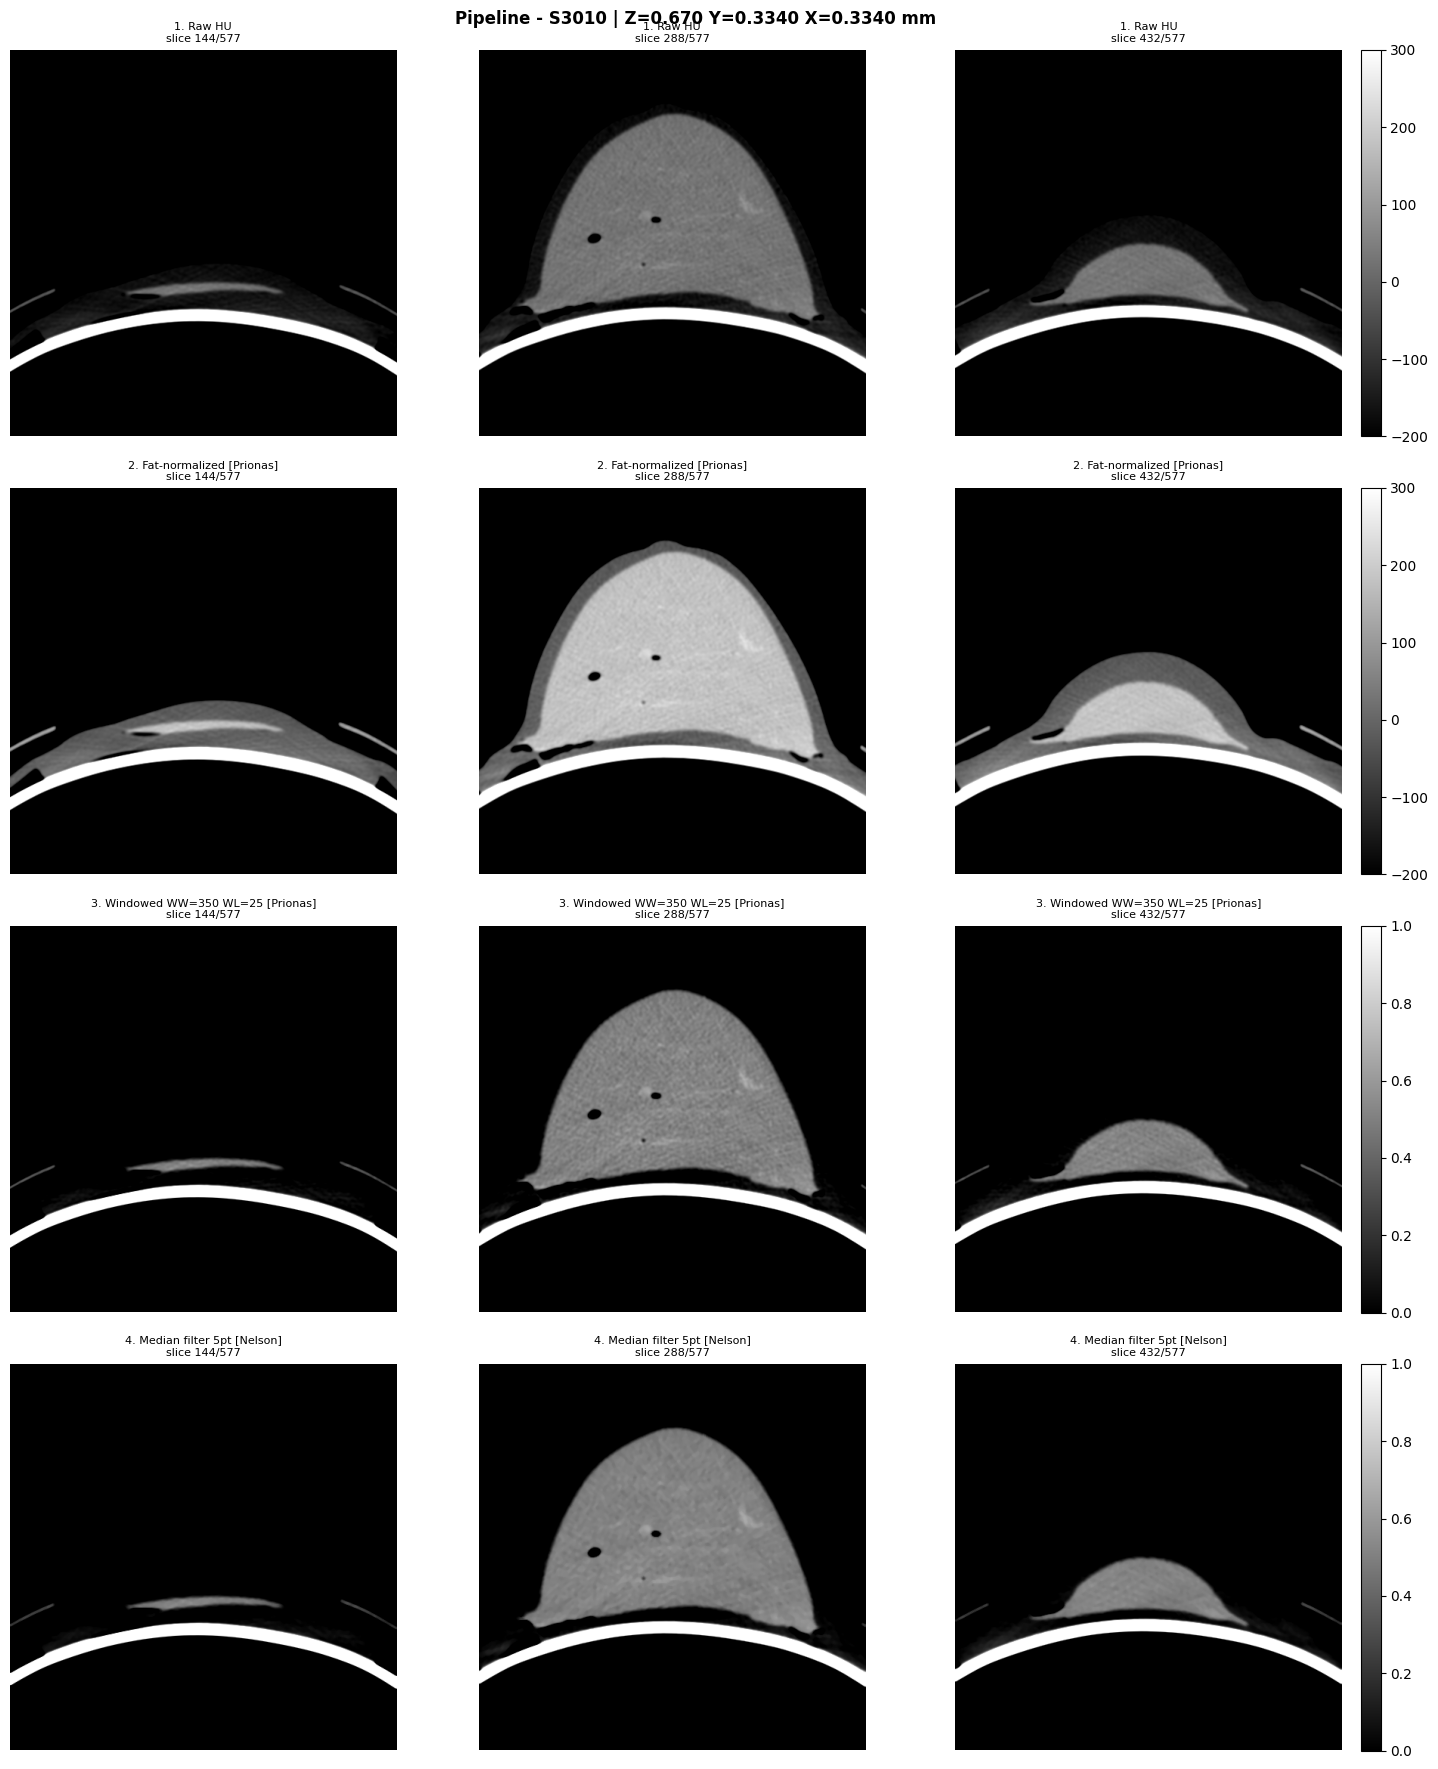

Saved: ./output/figures/paper_based/pipeline_S3010.png


In [6]:
# ============================================================
# CELL 6 - Full pipeline visualization (4 rows x 3 slices)
# ============================================================

def visualize_full_pipeline(hu_vol, norm_vol, wind_vol, filt_vol, series_name, spacing):
    n, idxs = hu_vol.shape[0], [hu_vol.shape[0]//4, hu_vol.shape[0]//2, 3*hu_vol.shape[0]//4]
    rows_data = [
        (hu_vol,   "1. Raw HU",                              dict(vmin=-200, vmax=300)),
        (norm_vol, "2. Fat-normalized [Prionas]",         dict(vmin=-200, vmax=300)),
        (wind_vol, "3. Windowed WW=350 WL=25 [Prionas]", dict(vmin=0, vmax=1)),
        (filt_vol, "4. Median filter 5pt [Nelson]",       dict(vmin=0, vmax=1)),
    ]
    fig, axes = plt.subplots(4, 3, figsize=(15, 18))
    fig.suptitle(f"Pipeline - {series_name} | Z={spacing[0]:.3f} Y={spacing[1]:.4f} X={spacing[2]:.4f} mm",
                 fontsize=12, fontweight='bold')
    for row_idx, (vol, label, kwargs) in enumerate(rows_data):
        for col_idx, sl in enumerate(idxs):
            ax = axes[row_idx, col_idx]
            im = ax.imshow(vol[sl], cmap='gray', **kwargs)
            ax.set_title(f"{label}\nslice {sl}/{n}", fontsize=8); ax.axis('off')
            if col_idx == 2: plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    out = f"./output/figures/paper_based/pipeline_{series_name}.png"
    plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
    print(f"Saved: {out}")


visualize_full_pipeline(hu_S2010, norm_S2010, windowed_S2010, filtered_S2010, "S2010", spacing_S2010)
visualize_full_pipeline(hu_S3010, norm_S3010, windowed_S3010, filtered_S3010, "S3010", spacing_S3010)


---
## Step 5 - Threshold-based Segmentation

Main deliverable for the 30/03 meeting.

| Histogram | Algorithm | When |
|---|---|---|
| Multimodal | Valley-seeking [Chen] | Real patient data |
| Unimodal | Five-subinterval [Chen] | Phantom data |

**Expected threshold [Nelson2008]:** 130-145 HU (valley between fat ~126 and glandular ~152).

**Quality without ground truth [Prionas, Caballo]:**
1. Mean HU per region vs. literature values
2. Tissue proportions: ~73% fat / ~17% glandular [Nelson]
3. Visual inspection of histogram with threshold annotated


In [ ]:
# ============================================================
# CONFIG - STEP 5: Tune HU range for normalized volume histogram and threshold selection
# Ref: Chen (valley-seeking) | Nelson (HU reference)
# ============================================================
from scipy.ndimage import gaussian_filter1d

# Volume to use for segmentation (fat-normalized)
# After normalization: fat ~0 HU | glandular ~+150 HU | valley ~+40-60 HU
SEG_VOLUME = {
    "S2010": norm_S2010,
    "S3010": norm_S3010,
}

# HU range for the histogram — tuned for the normalized volume
HU_RANGE = (-300, 250)

# HU range for tissue masks — excludes air and metal
TISSUE_HU_MIN = -300
TISSUE_HU_MAX = 500

# Number of histogram bins
N_BINS = 500

# Gaussian smoothing sigma for peak detection
# Increase if too many sub-peaks are still detected (try 10, 12, 15)
SMOOTH_SIGMA = 8

# Reference lines on the plot
REF_FAT_HU   =   0    # fat after normalization
REF_GLAND_HU = 150    # glandular after normalization

print("Config loaded.")
print(f"  HU range:       {HU_RANGE}")
print(f"  Smooth sigma:   {SMOOTH_SIGMA}")
print(f"  fat_hu_S2010:   {fat_hu_S2010:.1f} HU")
print(f"  fat_hu_S3010:   {fat_hu_S3010:.1f} HU")
print(f"  Expected peaks (norm. vol.): fat ~{REF_FAT_HU} HU | glandular ~{REF_GLAND_HU} HU")

Config loaded.
  HU range:       (-300, 250)
  Smooth sigma:   8
  fat_hu_S2010:   -157.8 HU
  fat_hu_S3010:   -152.2 HU
  Expected peaks (norm. vol.): fat ~0 HU | glandular ~150 HU


In [8]:
# ============================================================
# CELL 7 - STEP 5a: Histogram analysis + threshold selection
# Ref: Chen (valley-seeking) | Nelson (HU reference)
# Gaussian smoothing applied before peak detection to avoid
# sub-peak fragmentation inside the fat distribution
# ============================================================

def analyze_histogram_and_threshold(seg_volume, series_name,
                                     hu_range=HU_RANGE, n_bins=N_BINS):
    """
    Compute HU histogram on the normalized volume, smooth it with
    a Gaussian filter to suppress the many small sub-peaks inside
    the fat distribution, then find the valley between the two
    dominant tissue peaks using valley-seeking [Chen].

    Without smoothing, the jagged fat distribution generates many
    small local maxima and the algorithm selects the wrong pair,
    placing the threshold far to the left inside the fat region.

    On the normalized volume (HU_norm = HU - HU_mean_fat):
      - Fat peak:       ~0   HU  (centered by construction)
      - Glandular peak: ~+150 HU
      - Expected valley: ~+40 to +60 HU
    """
    flat = seg_volume.flatten()
    flat = flat[(flat >= hu_range[0]) & (flat <= hu_range[1])]

    hist, bin_edges = np.histogram(flat, bins=n_bins, range=hu_range)
    bin_centers     = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Smooth histogram before peak detection
    hist_smooth = gaussian_filter1d(hist.astype(float), sigma=SMOOTH_SIGMA)

    peaks, _ = find_peaks(hist_smooth,
                          prominence=hist_smooth.max() * 0.05,
                          distance=n_bins // 10)

    print(f"[{series_name}] Peaks found after smoothing (sigma={SMOOTH_SIGMA}): {len(peaks)}")
    for p in peaks:
        print(f"  -> {bin_centers[p]:.1f} HU  ({hist[p]:,} voxels)")

    if len(peaks) >= 2:
        print(f"[{series_name}] MULTIMODAL -> valley-seeking [Chen]")

        # Sort by HU value: leftmost = fat, next = glandular
        peaks_sorted = peaks[np.argsort(bin_centers[peaks])]
        p_fat   = peaks_sorted[0]
        p_gland = peaks_sorted[1]

        print(f"[{series_name}] Fat peak:       {bin_centers[p_fat]:.1f} HU")
        print(f"[{series_name}] Glandular peak: {bin_centers[p_gland]:.1f} HU")

        # Find the deepest valley between the two peaks on the smoothed histogram
        valley_idx, _ = find_peaks(-hist_smooth)
        between = valley_idx[(valley_idx > p_fat) & (valley_idx < p_gland)]

        if len(between) > 0:
            best      = between[np.argmin(hist_smooth[between])]
            threshold = float(bin_centers[best])
        else:
            threshold = float((bin_centers[p_fat] + bin_centers[p_gland]) / 2)
            print(f"[{series_name}] No clear valley, using midpoint")

    else:
        print(f"[{series_name}] UNIMODAL -> five-subinterval [Chen]")
        threshold = hu_range[0] + 2 * ((hu_range[1] - hu_range[0]) / 5)

    print(f"[{series_name}] Selected threshold: {threshold:.1f} HU")

    # Return original unsmoothed hist for plotting
    return threshold, hist, bin_centers, peaks


# --- RUN ---
print("=== STEP 5a: Histogram analysis (normalized volume) ===")
thresh_S2010, hist_S2010, bins_S2010, peaks_S2010 = analyze_histogram_and_threshold(
    SEG_VOLUME["S2010"], "S2010")

thresh_S3010, hist_S3010, bins_S3010, peaks_S3010 = analyze_histogram_and_threshold(
    SEG_VOLUME["S3010"], "S3010")

print(f"\nThreshold S2010: {thresh_S2010:.1f} HU")
print(f"Threshold S3010: {thresh_S3010:.1f} HU")
print("Expected: between fat peak (~0 HU) and glandular peak (~+150 HU)")
print("          roughly +40 to +60 HU on the normalized scale")

=== STEP 5a: Histogram analysis (normalized volume) ===
[S2010] Peaks found after smoothing (sigma=8): 2
  -> -36.5 HU  (125,177 voxels)
  -> 184.6 HU  (248,791 voxels)
[S2010] MULTIMODAL -> valley-seeking [Chen]
[S2010] Fat peak:       -36.5 HU
[S2010] Glandular peak: 184.6 HU
[S2010] Selected threshold: 106.4 HU
[S3010] Peaks found after smoothing (sigma=8): 2
  -> -13.4 HU  (218,488 voxels)
  -> 180.1 HU  (515,718 voxels)
[S3010] MULTIMODAL -> valley-seeking [Chen]
[S3010] Fat peak:       -13.4 HU
[S3010] Glandular peak: 180.1 HU
[S3010] Selected threshold: 88.9 HU

Threshold S2010: 106.4 HU
Threshold S3010: 88.9 HU
Expected: between fat peak (~0 HU) and glandular peak (~+150 HU)
          roughly +40 to +60 HU on the normalized scale


=== STEP 5b: Apply threshold ===

[S2010] Threshold applied: 106.4 HU (normalized volume)
[S2010] Fat:       53.8%  mean=-55.6 HU
[S2010] Glandular: 46.2%  mean=189.6 HU
[S2010] Expected [Nelson]: ~73% fat | ~17% glandular
[S2010] Glandular volume: 1031915 mm3 (1031.91 cm3)


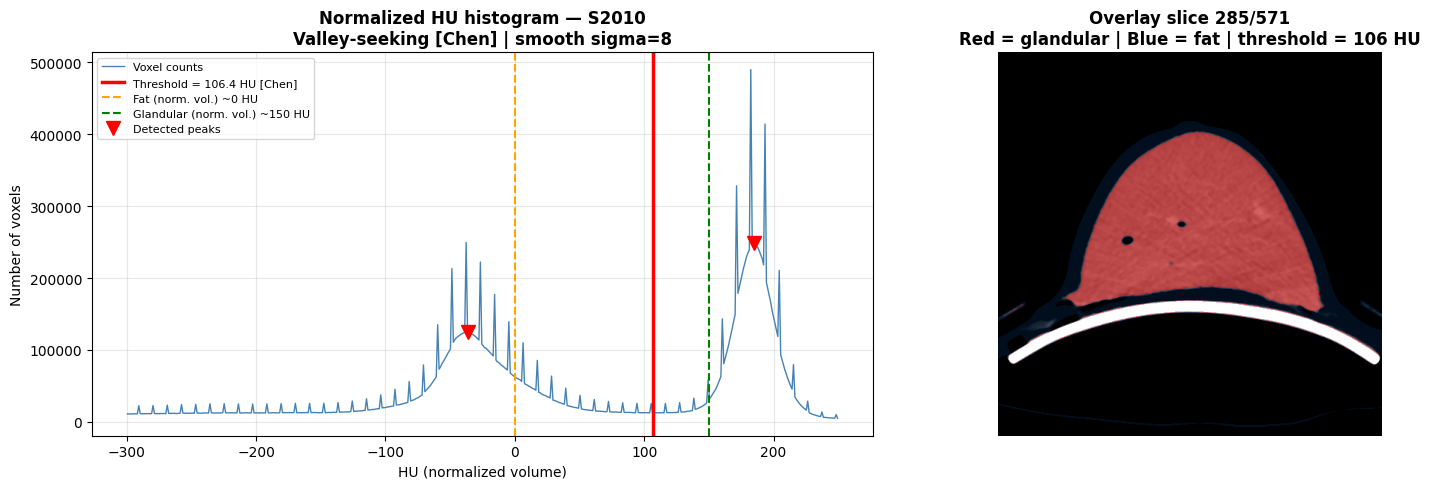

[S2010] Saved: ./output/figures/paper_based/segmentation_S2010.png

[S3010] Threshold applied: 88.9 HU (normalized volume)
[S3010] Fat:       49.1%  mean=-28.7 HU
[S3010] Glandular: 50.9%  mean=183.0 HU
[S3010] Expected [Nelson]: ~73% fat | ~17% glandular
[S3010] Glandular volume: 1053276 mm3 (1053.28 cm3)


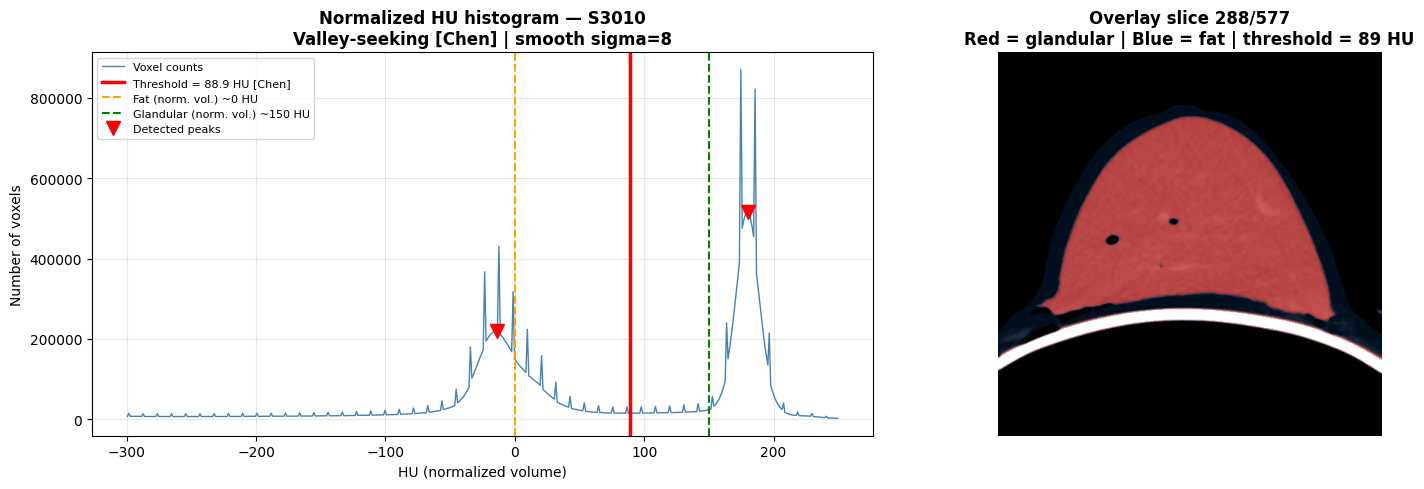

[S3010] Saved: ./output/figures/paper_based/segmentation_S3010.png


In [9]:
# ============================================================
# CELL 8 - STEP 5b: Apply threshold + quality evaluation
# Ref: Chen, Nelson, Caballo, Prionas
# Uses SEG_VOLUME (normalized) and TISSUE_HU_MIN/MAX from CONFIG
# ============================================================

def apply_threshold_and_evaluate(seg_volume, filtered_volume, threshold,
                                  hist, bin_centers, peaks,
                                  series_name, spacing):
    """
    Apply the threshold on the normalized volume and evaluate quality.

    Masks (fat / glandular) are computed on seg_volume (normalized).
    Visualization uses filtered_volume (windowed, for display only).

    Quality metrics without ground truth [Prionas, Caballo]:
      1. Mean HU of each region vs. expected in normalized volume
         fat ~0 HU | glandular ~+150 HU
      2. Tissue proportions vs. Nelson: ~73% fat | ~17% glandular
      3. Visual inspection of histogram and segmentation overlay
    """
    tissue_mask = (seg_volume > TISSUE_HU_MIN) & (seg_volume < TISSUE_HU_MAX)
    gland_mask  = (seg_volume > threshold)  & tissue_mask
    fat_mask    = (seg_volume <= threshold) & tissue_mask

    total      = fat_mask.sum() + gland_mask.sum()
    mean_fat   = float(np.mean(seg_volume[fat_mask]))   if fat_mask.sum()   > 0 else 0
    mean_gland = float(np.mean(seg_volume[gland_mask])) if gland_mask.sum() > 0 else 0
    pct_fat    = 100 * fat_mask.sum()   / total if total > 0 else 0
    pct_gland  = 100 * gland_mask.sum() / total if total > 0 else 0
    vox_vol    = spacing[0] * spacing[1] * spacing[2]
    vol_mm3    = gland_mask.sum() * vox_vol

    print(f"\n[{series_name}] Threshold applied: {threshold:.1f} HU (normalized volume)")
    print(f"[{series_name}] Fat:       {pct_fat:.1f}%  mean={mean_fat:.1f} HU")
    print(f"[{series_name}] Glandular: {pct_gland:.1f}%  mean={mean_gland:.1f} HU")
    print(f"[{series_name}] Expected [Nelson]: ~73% fat | ~17% glandular")
    print(f"[{series_name}] Glandular volume: {vol_mm3:.0f} mm3 ({vol_mm3/1000:.2f} cm3)")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Annotated histogram (original unsmoothed)
    ax = axes[0]
    ax.plot(bin_centers, hist, color='steelblue', lw=1, label='Voxel counts')
    ax.axvline(threshold, color='red', lw=2.5,
               label=f'Threshold = {threshold:.1f} HU [Chen]')
    ax.axvline(REF_FAT_HU, color='orange', lw=1.5, ls='--',
               label=f'Fat (norm. vol.) ~{REF_FAT_HU} HU')
    ax.axvline(REF_GLAND_HU, color='green', lw=1.5, ls='--',
               label=f'Glandular (norm. vol.) ~{REF_GLAND_HU} HU')
    if len(peaks) > 0:
        ax.plot(bin_centers[peaks], hist[peaks], 'rv', ms=10, label='Detected peaks')
    ax.set_xlabel('HU (normalized volume)')
    ax.set_ylabel('Number of voxels')
    ax.set_title(f'Normalized HU histogram — {series_name}\n'
                 f'Valley-seeking [Chen] | smooth sigma={SMOOTH_SIGMA}',
                 fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Segmentation overlay on central slice
    mid = filtered_volume.shape[0] // 2
    axes[1].imshow(filtered_volume[mid], cmap='gray', vmin=0, vmax=1)
    ov = np.zeros((*filtered_volume[mid].shape, 4))
    ov[gland_mask[mid]] = [1, 0, 0, 0.45]    # red   = glandular
    ov[fat_mask[mid]]   = [0, 0.5, 1, 0.12]  # light blue = fat
    axes[1].imshow(ov)
    axes[1].set_title(f'Overlay slice {mid}/{filtered_volume.shape[0]}\n'
                      f'Red = glandular | Blue = fat | threshold = {threshold:.0f} HU',
                      fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    out = f'./output/figures/paper_based/segmentation_{series_name}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"[{series_name}] Saved: {out}")

    return gland_mask, fat_mask

# --- RUN ---
print("=== STEP 5b: Apply threshold ===")
mask_lesion_S2010, mask_fat_S2010 = apply_threshold_and_evaluate(
    SEG_VOLUME["S2010"], filtered_S2010,
    thresh_S2010, hist_S2010, bins_S2010, peaks_S2010,
    "S2010", spacing_S2010)

mask_lesion_S3010, mask_fat_S3010 = apply_threshold_and_evaluate(
    SEG_VOLUME["S3010"], filtered_S3010,
    thresh_S3010, hist_S3010, bins_S3010, peaks_S3010,
    "S3010", spacing_S3010)

In [10]:
# ============================================================
# CELL - Inclusion segmentation inside the phantom
# Step 1: isolate the phantom body (fat + glandular combined)
# ============================================================

# Phantom body = everything already segmented (fat + glandular)
phantom_mask_S2010 = mask_fat_S2010 | mask_lesion_S2010
phantom_mask_S3010 = mask_fat_S3010 | mask_lesion_S3010

# Extract HU values inside the phantom only (normalized volume)
phantom_hu_S2010 = SEG_VOLUME["S2010"][phantom_mask_S2010]
phantom_hu_S3010 = SEG_VOLUME["S3010"][phantom_mask_S3010]

print(f"S2010 phantom voxels: {phantom_hu_S2010.size:,}")
print(f"S2010 HU inside phantom: min={phantom_hu_S2010.min():.1f}  max={phantom_hu_S2010.max():.1f}")
print(f"S3010 phantom voxels: {phantom_hu_S3010.size:,}")
print(f"S3010 HU inside phantom: min={phantom_hu_S3010.min():.1f}  max={phantom_hu_S3010.max():.1f}")

S2010 phantom voxels: 23,203,382
S2010 HU inside phantom: min=-299.2  max=499.8
S3010 phantom voxels: 27,667,591
S3010 HU inside phantom: min=-299.8  max=499.2


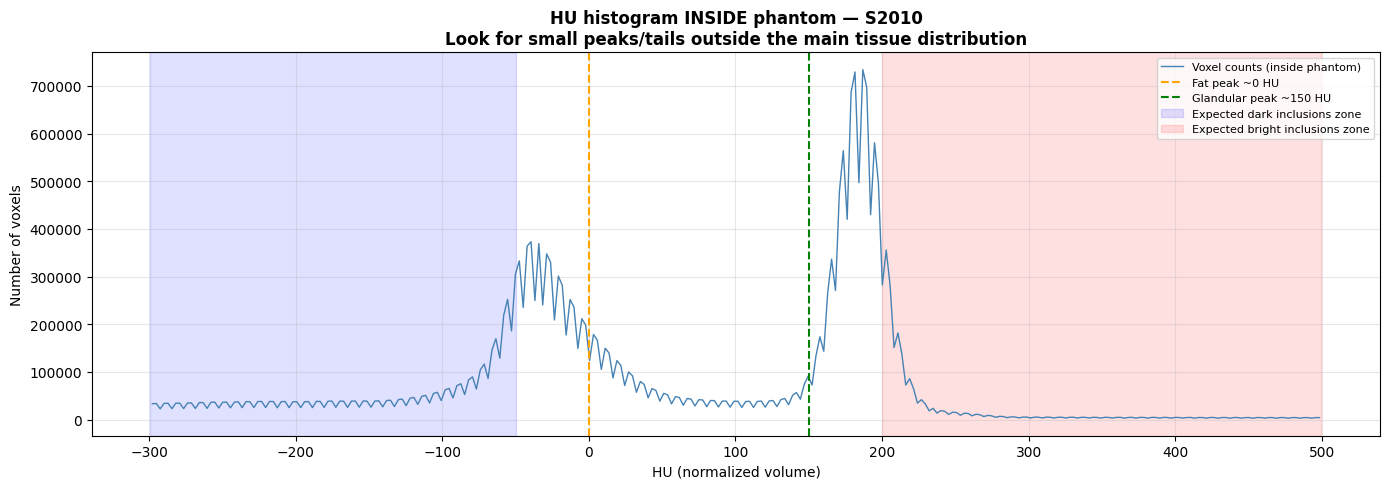

Saved: ./output/figures/paper_based/phantom_interior_histogram_S2010.png


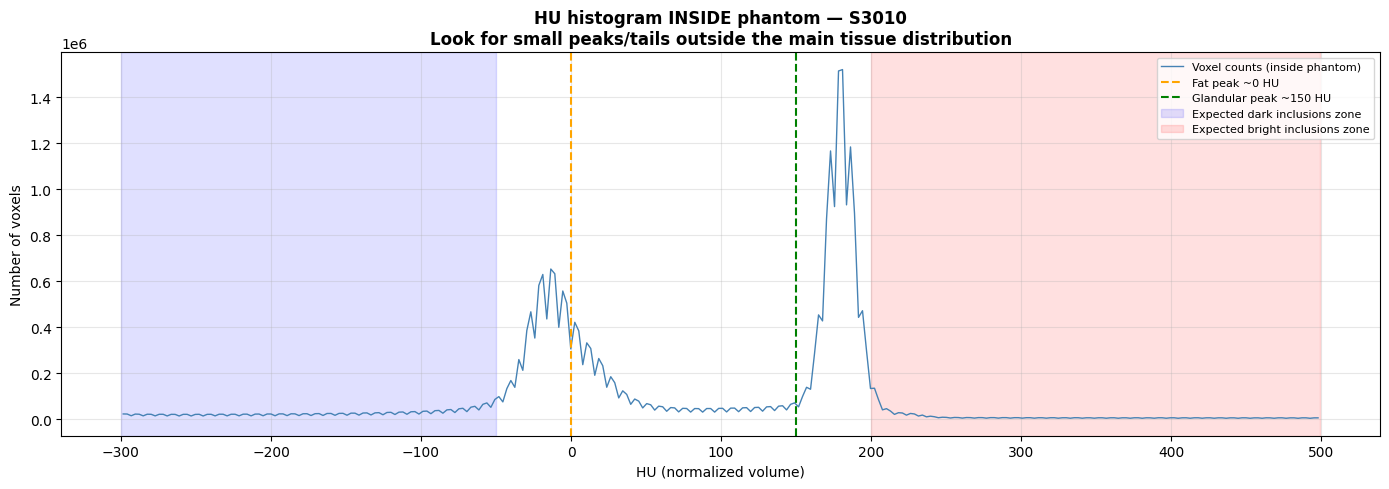

Saved: ./output/figures/paper_based/phantom_interior_histogram_S3010.png


In [11]:
# ============================================================
# Step 2: histogram inside phantom to identify inclusion HU ranges
# ============================================================

def plot_phantom_interior_histogram(phantom_hu, series_name, n_bins=300):
    """
    Plot the HU histogram of the phantom interior only.
    Inclusions will appear as small peaks or tails at the extremes
    of the distribution, separated from the main fat/glandular peaks.
    """
    fig, ax = plt.subplots(figsize=(14, 5))

    hist, edges = np.histogram(phantom_hu, bins=n_bins)
    centers     = (edges[:-1] + edges[1:]) / 2

    ax.plot(centers, hist, color='steelblue', lw=1, label='Voxel counts (inside phantom)')

    # Main tissue reference lines (normalized volume)
    ax.axvline(REF_FAT_HU,   color='orange', lw=1.5, ls='--',
               label=f'Fat peak ~{REF_FAT_HU} HU')
    ax.axvline(REF_GLAND_HU, color='green',  lw=1.5, ls='--',
               label=f'Glandular peak ~{REF_GLAND_HU} HU')

    # Highlight the tails where inclusions are expected
    # Dark inclusions: left tail (lower HU than fat)
    # Bright inclusions: right tail (higher HU than glandular)
    ax.axvspan(phantom_hu.min(), REF_FAT_HU - 50,
               alpha=0.12, color='blue',  label='Expected dark inclusions zone')
    ax.axvspan(REF_GLAND_HU + 50, phantom_hu.max(),
               alpha=0.12, color='red',   label='Expected bright inclusions zone')

    ax.set_xlabel('HU (normalized volume)')
    ax.set_ylabel('Number of voxels')
    ax.set_title(f'HU histogram INSIDE phantom — {series_name}\n'
                 f'Look for small peaks/tails outside the main tissue distribution',
                 fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    out = f'./output/figures/paper_based/phantom_interior_histogram_{series_name}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {out}")
    return hist, centers


hist_int_S2010, centers_int_S2010 = plot_phantom_interior_histogram(
    phantom_hu_S2010, "S2010")
hist_int_S3010, centers_int_S3010 = plot_phantom_interior_histogram(
    phantom_hu_S3010, "S3010")

=== Inclusion segmentation ===
[S2010] Dark inclusions:   3,091,449 voxels | 297372 mm3 (297.37 cm3)
[S2010] Bright inclusions: 2,142,159 voxels | 206058 mm3 (206.06 cm3)


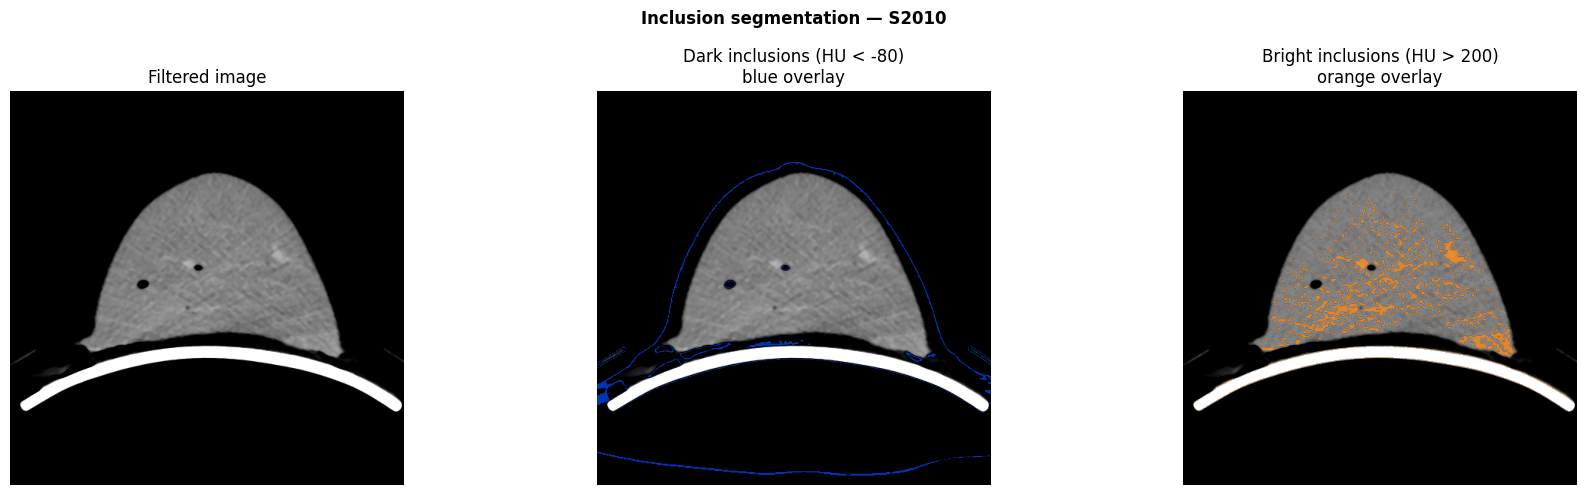

Saved: ./output/figures/paper_based/inclusions_S2010.png
[S3010] Dark inclusions:   1,836,792 voxels | 137274 mm3 (137.27 cm3)
[S3010] Bright inclusions: 1,125,802 voxels | 84137 mm3 (84.14 cm3)


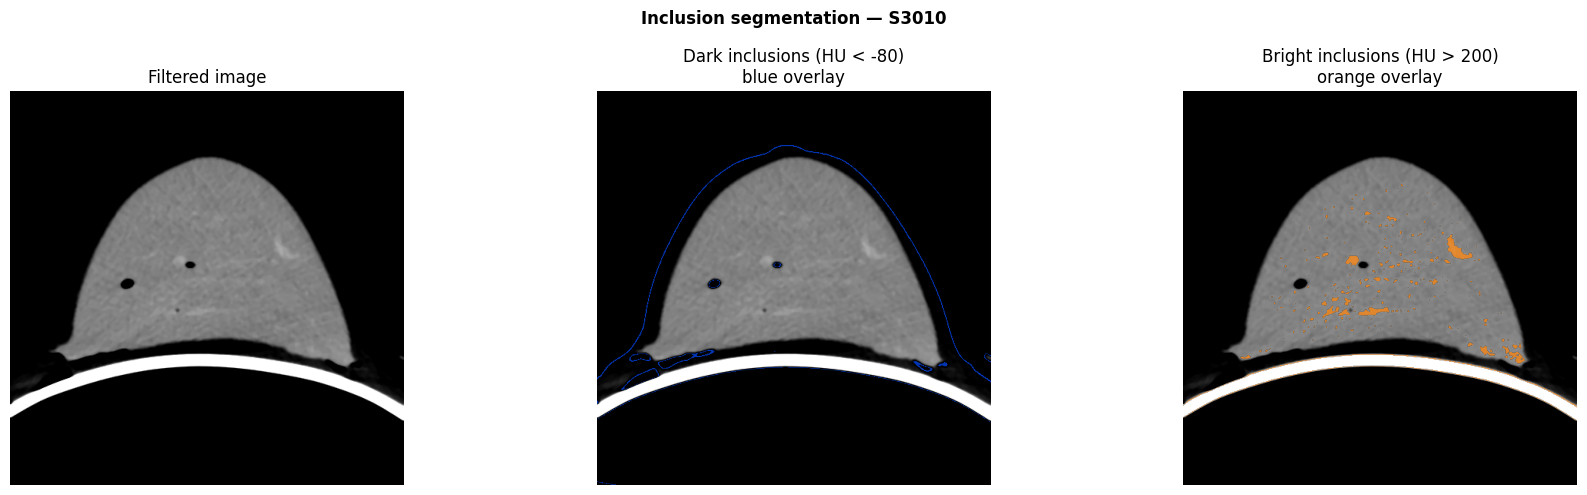

Saved: ./output/figures/paper_based/inclusions_S3010.png


In [12]:
# ============================================================
# Step 3: segment inclusions using dedicated HU ranges
# Tune these values after looking at the histogram from Step 2
# ============================================================

# --- TUNE THESE VALUES based on the histogram output above ---
# Dark inclusions: voxels with HU significantly BELOW the fat peak
INCL_DARK_MAX  = -80   # upper bound for dark inclusions (HU, normalized)
INCL_DARK_MIN  = -300  # lower bound (exclude air)

# Bright inclusions: voxels with HU significantly ABOVE the glandular peak
INCL_BRIGHT_MIN = 200  # lower bound for bright inclusions (HU, normalized)
INCL_BRIGHT_MAX = 500  # upper bound (exclude metal)
# -------------------------------------------------------------

def segment_inclusions(seg_volume, phantom_mask, filtered_volume,
                        series_name, spacing):
    """
    Segment dark and bright inclusions inside the phantom body.
    Works only within phantom_mask to avoid false positives outside.
    """
    # Dark inclusions (lower HU than fat)
    dark_mask   = (seg_volume >= INCL_DARK_MIN)  & \
                  (seg_volume <= INCL_DARK_MAX)   & phantom_mask

    # Bright inclusions (higher HU than glandular)
    bright_mask = (seg_volume >= INCL_BRIGHT_MIN) & \
                  (seg_volume <= INCL_BRIGHT_MAX)  & phantom_mask

    vox_vol = spacing[0] * spacing[1] * spacing[2]

    print(f"[{series_name}] Dark inclusions:   {dark_mask.sum():,} voxels "
          f"| {dark_mask.sum()*vox_vol:.0f} mm3 "
          f"({dark_mask.sum()*vox_vol/1000:.2f} cm3)")
    print(f"[{series_name}] Bright inclusions: {bright_mask.sum():,} voxels "
          f"| {bright_mask.sum()*vox_vol:.0f} mm3 "
          f"({bright_mask.sum()*vox_vol/1000:.2f} cm3)")

    # Visualization
    mid = filtered_volume.shape[0] // 2
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Inclusion segmentation — {series_name}', fontweight='bold')

    axes[0].imshow(filtered_volume[mid], cmap='gray', vmin=0, vmax=1)
    axes[0].set_title('Filtered image'); axes[0].axis('off')

    axes[1].imshow(filtered_volume[mid], cmap='gray', vmin=0, vmax=1)
    ov1 = np.zeros((*filtered_volume[mid].shape, 4))
    ov1[dark_mask[mid]]  = [0, 0.3, 1, 0.7]   # blue  = dark inclusions
    axes[1].imshow(ov1)
    axes[1].set_title(f'Dark inclusions (HU < {INCL_DARK_MAX})\nblue overlay')
    axes[1].axis('off')

    axes[2].imshow(filtered_volume[mid], cmap='gray', vmin=0, vmax=1)
    ov2 = np.zeros((*filtered_volume[mid].shape, 4))
    ov2[bright_mask[mid]] = [1, 0.5, 0, 0.7]  # orange = bright inclusions
    axes[2].imshow(ov2)
    axes[2].set_title(f'Bright inclusions (HU > {INCL_BRIGHT_MIN})\norange overlay')
    axes[2].axis('off')

    plt.tight_layout()
    out = f'./output/figures/paper_based/inclusions_{series_name}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {out}")

    return dark_mask, bright_mask


print("=== Inclusion segmentation ===")
dark_S2010, bright_S2010 = segment_inclusions(
    SEG_VOLUME["S2010"], phantom_mask_S2010, filtered_S2010,
    "S2010", spacing_S2010)

dark_S3010, bright_S3010 = segment_inclusions(
    SEG_VOLUME["S3010"], phantom_mask_S3010, filtered_S3010,
    "S3010", spacing_S3010)